# Notebook 07: SARSA — On-Policy TD Control

**Series:** Reinforcement Learning Basics (7/20)

---

## 1. From Prediction to Control

TD(0) estimates $V^\pi$. For **control**, we need $Q(s,a)$ to improve the policy.

## 2. SARSA Update

$$\boxed{Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha \Big[ R_{t+1} + \gamma Q(S_{t+1}, A_{t+1}) - Q(S_t, A_t) \Big]}$$

**Name origin:** Uses the quintuple $(S_t, A_t, R_{t+1}, S_{t+1}, A_{t+1})$

**On-Policy:** The next action $A_{t+1}$ is chosen by the **same** $\varepsilon$-greedy policy we're improving.

## 3. Expected SARSA

$$Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha \Big[ R_{t+1} + \gamma \sum_a \pi(a|S_{t+1}) Q(S_{t+1}, a) - Q(S_t, A_t) \Big]$$

Uses the **expected value** over next actions instead of a sample. Lower variance than SARSA.

## 4. SARSA is "Safe"

Because SARSA is on-policy, it accounts for the possibility of future exploration (random actions). This means it learns to **avoid dangerous states** even if the optimal path goes near them — it knows it might accidentally step into them.

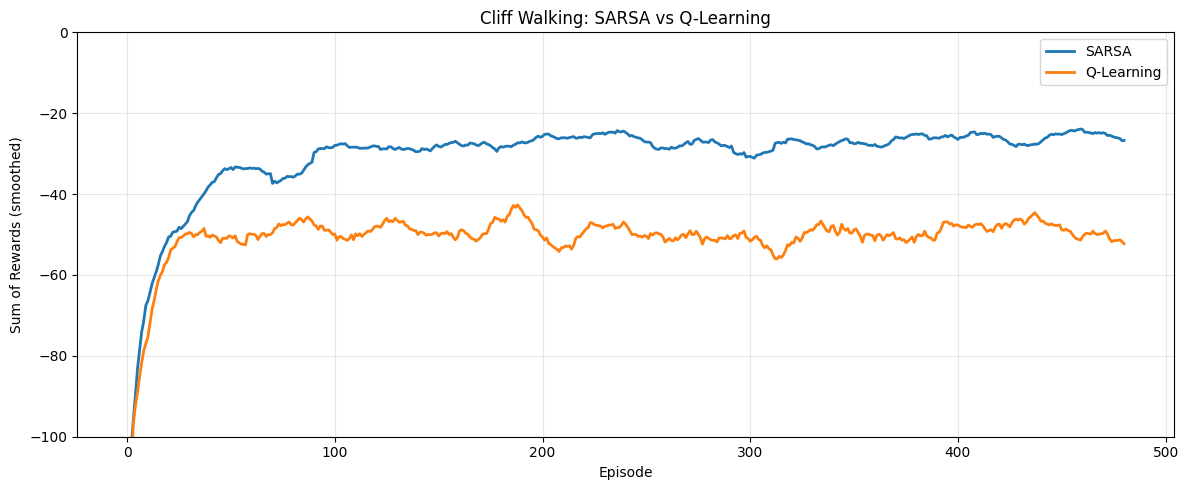

SARSA path (safe): [(3, 0), (2, 0), (1, 0), (0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 9), (0, 10), (0, 11)] ...
Q-Learning path (optimal): [(3, 0), (2, 0), (2, 1), (2, 2), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (2, 8), (2, 9), (2, 10), (2, 11), (3, 11)] ...


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# Cliff Walking Environment
# ============================================
class CliffWalking:
    def __init__(self, height=4, width=12):
        self.height = height
        self.width = width
        self.start = (height-1, 0)
        self.goal = (height-1, width-1)
        self.cliff = [(height-1, c) for c in range(1, width-1)]
        self.state = self.start

    def reset(self):
        self.state = self.start
        return self.state

    def step(self, action):
        r, c = self.state
        if action == 0: r = max(0, r-1)       # up
        elif action == 1: c = min(self.width-1, c+1)  # right
        elif action == 2: r = min(self.height-1, r+1)  # down
        elif action == 3: c = max(0, c-1)       # left

        self.state = (r, c)
        if self.state in self.cliff:
            self.state = self.start
            return self.state, -100, False
        elif self.state == self.goal:
            return self.state, -1, True
        else:
            return self.state, -1, False

def epsilon_greedy(Q, state, epsilon, n_actions=4):
    if np.random.random() < epsilon:
        return np.random.randint(n_actions)
    return np.argmax(Q[state])

# ============================================
# SARSA
# ============================================
def sarsa(env, n_episodes=500, alpha=0.5, gamma=1.0, epsilon=0.1):
    Q = {}
    rewards_per_episode = []
    for ep in range(n_episodes):
        state = env.reset()
        if state not in Q: Q[state] = np.zeros(4)
        action = epsilon_greedy(Q, state, epsilon)
        total_reward = 0
        for _ in range(10000):
            next_state, reward, done = env.step(action)
            if next_state not in Q: Q[next_state] = np.zeros(4)
            next_action = epsilon_greedy(Q, next_state, epsilon)
            Q[state][action] += alpha * (reward + gamma * Q[next_state][next_action] - Q[state][action])
            state, action = next_state, next_action
            total_reward += reward
            if done: break
        rewards_per_episode.append(total_reward)
    return Q, rewards_per_episode

# ============================================
# Q-Learning (for comparison)
# ============================================
def q_learning(env, n_episodes=500, alpha=0.5, gamma=1.0, epsilon=0.1):
    Q = {}
    rewards_per_episode = []
    for ep in range(n_episodes):
        state = env.reset()
        if state not in Q: Q[state] = np.zeros(4)
        total_reward = 0
        for _ in range(10000):
            action = epsilon_greedy(Q, state, epsilon)
            next_state, reward, done = env.step(action)
            if next_state not in Q: Q[next_state] = np.zeros(4)
            Q[state][action] += alpha * (reward + gamma * np.max(Q[next_state]) - Q[state][action])
            state = next_state
            total_reward += reward
            if done: break
        rewards_per_episode.append(total_reward)
    return Q, rewards_per_episode

env = CliffWalking()

# Average over multiple runs
n_runs = 50
sarsa_rewards = np.zeros(500)
ql_rewards = np.zeros(500)

for _ in range(n_runs):
    _, sr = sarsa(CliffWalking(), 500)
    _, qr = q_learning(CliffWalking(), 500)
    sarsa_rewards += np.array(sr)
    ql_rewards += np.array(qr)

sarsa_rewards /= n_runs
ql_rewards /= n_runs

# Smooth
def smooth(x, w=10):
    return np.convolve(x, np.ones(w)/w, mode='valid')

plt.figure(figsize=(12, 5))
plt.plot(smooth(sarsa_rewards, 20), label='SARSA', linewidth=2)
plt.plot(smooth(ql_rewards, 20), label='Q-Learning', linewidth=2)
plt.xlabel('Episode')
plt.ylabel('Sum of Rewards (smoothed)')
plt.title('Cliff Walking: SARSA vs Q-Learning')
plt.legend()
plt.ylim(-100, 0)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Show learned paths
Q_s, _ = sarsa(CliffWalking(), 500)
Q_q, _ = q_learning(CliffWalking(), 500)

def extract_path(Q, env):
    state = env.reset()
    path = [state]
    for _ in range(50):
        if state not in Q:
            break
        action = np.argmax(Q[state])
        state, _, done = env.step(action)
        path.append(state)
        if done: break
    return path

path_sarsa = extract_path(Q_s, CliffWalking())
path_ql = extract_path(Q_q, CliffWalking())

print("SARSA path (safe):", path_sarsa[:15], "...")
print("Q-Learning path (optimal):", path_ql[:15], "...")

## Summary

| Algorithm | Update | On/Off-Policy |
|-----------|--------|--------------|
| **SARSA** | $Q(s,a) \leftarrow Q(s,a) + \alpha[R + \gamma Q(s',a') - Q(s,a)]$ | On-Policy |
| **Expected SARSA** | $Q(s,a) \leftarrow Q(s,a) + \alpha[R + \gamma \sum_a \pi(a|s')Q(s',a) - Q(s,a)]$ | On-Policy |

**Key insight:** SARSA finds the **safe** path; Q-Learning finds the **optimal** path.

**Next:** Notebook 08 — Q-Learning